<a href="https://colab.research.google.com/github/RMoulla/MLW_Juin/blob/main/TP_Analyse_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travaux pratiques : analyse et prédiction du churn avec le machine learning**

In [38]:
# Importer les données

import pandas as pd

dataset = pd.read_csv('customer_churn.csv')
dataset.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [39]:
dataset.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='object')

## Nettoyage des données

In [40]:
dataset.drop(columns = ['Names', 'Onboard_date', 'Location', 'Company'], inplace=True)
dataset.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


## Analyse exploratoire des données

In [41]:
# Import des librairies de visualisation des données

import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Statistiques descriptives

dataset.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


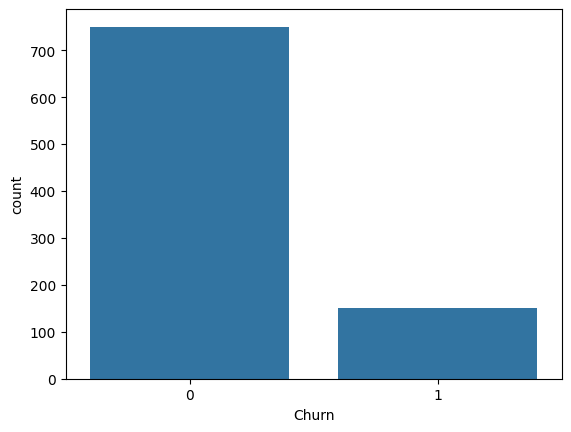

In [43]:
# Visualiser la distribution du churn

sns.countplot(x='Churn', data=dataset)
plt.show()

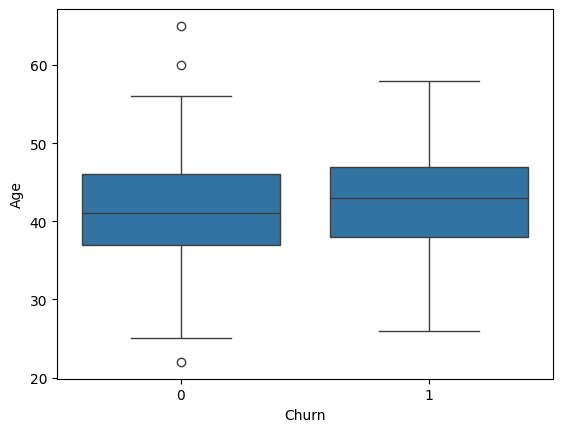

In [44]:
# Visualiser le churn en fonction de l'âge

sns.boxplot(x='Churn', y = 'Age', data=dataset)
plt.show()

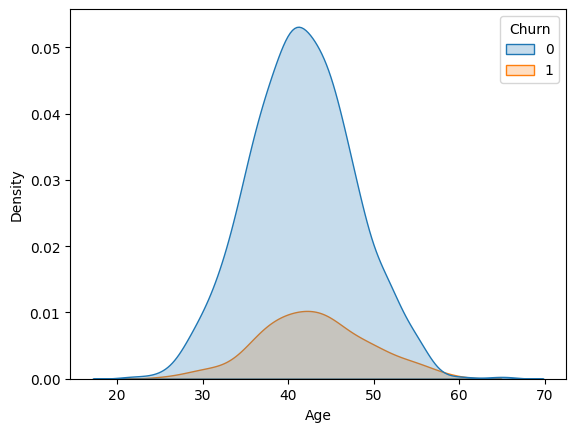

In [45]:
# Visualiser le churn en fonction de l'âge sous forme de densité

sns.kdeplot(x='Age', hue='Churn', data=dataset, fill=True)
plt.show()

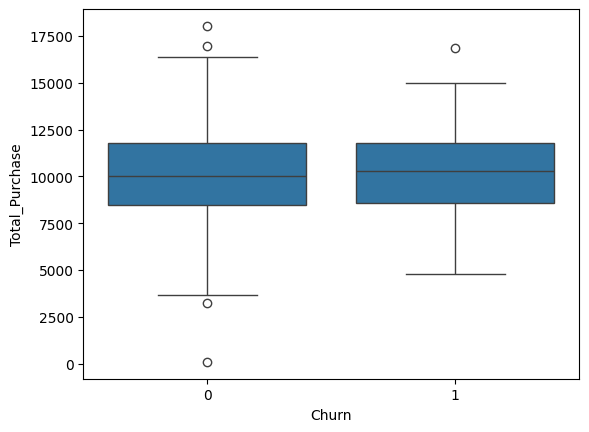

In [46]:
sns.boxplot(x='Churn', y = 'Total_Purchase', data=dataset)
plt.show()

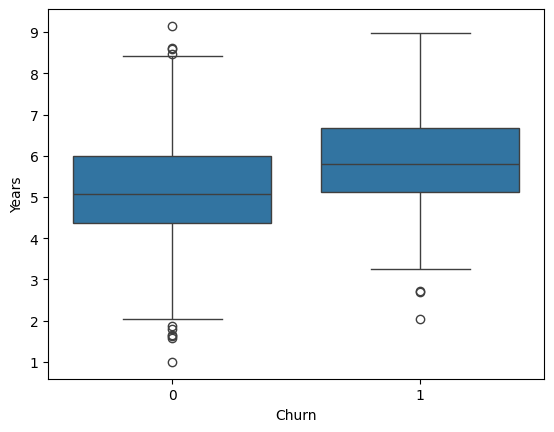

In [47]:
sns.boxplot(x='Churn', y = 'Years', data=dataset)
plt.show()

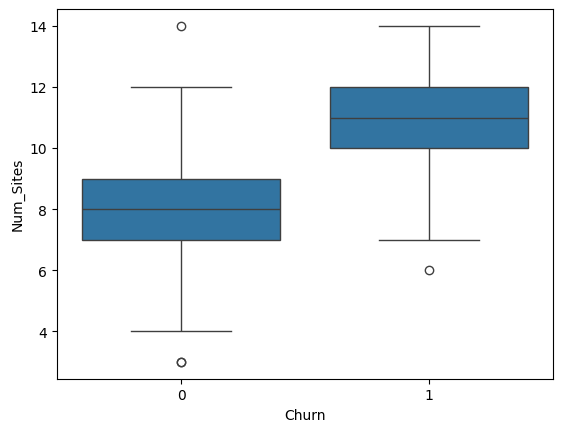

In [48]:
sns.boxplot(x='Churn', y = 'Num_Sites', data=dataset)
plt.show()

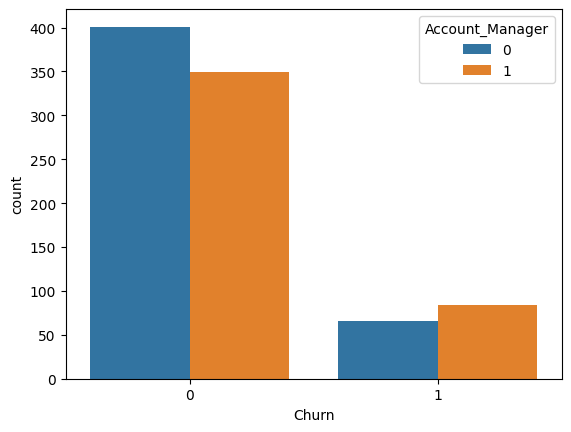

In [49]:
sns.countplot(x='Churn', hue = 'Account_Manager', data=dataset)
plt.show()

## Analyse des déterminants du churn avec du machine learning

In [50]:
# isoler les X et y

X = dataset.drop(columns = ['Churn'])
y = dataset['Churn']

In [51]:
# Partitionner les données en train et test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
687,43.0,9891.30,0,5.75,11.0
705,46.0,7638.13,1,4.91,9.0
296,38.0,11803.58,1,6.97,6.0
172,43.0,6298.75,1,4.51,9.0
863,48.0,11316.41,1,4.74,10.0


$$\ln(\frac{p(x)}{1-p(x)}) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 +...$$

In [52]:
# Entraîner un modèle de régression logisitique avec statsmodels

import statsmodels.api as sm


X_train = sm.add_constant(X_train)
logit = sm.Logit(y_train, X_train).fit()
print(logit.summary())

Optimization terminated successfully.
         Current function value: 0.259923
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  630
Model:                          Logit   Df Residuals:                      624
Method:                           MLE   Df Model:                            5
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.4295
Time:                        07:21:25   Log-Likelihood:                -163.75
converged:                       True   LL-Null:                       -287.05
Covariance Type:            nonrobust   LLR p-value:                 2.954e-51
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -20.0003      2.124     -9.417      0.000     -24.163     -15.838
Age           

## Prédiction du churn

In [53]:
# importer les métriques de classification : accuracy, rappel, précision et f1-score

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

X_test = sm.add_constant(X_test)
y_pred = logit.predict(X_test)

# Transformer les probabilité en 1 et 0
y_pred = (y_pred > 0.5).astype(int)

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.9
0.6046511627906976
0.7222222222222222
0.6582278481012658


Standardisation des données

$$ x→ \frac{x-\bar{x}}{\sigma}$$

In [54]:
# Entraîner une régression logistique avec sklearn

from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standatdisation des données

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logit = LogisticRegression()
logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.9
0.6046511627906976
0.7222222222222222
0.6582278481012658


In [55]:
# Pipeline de standardisation et d'entraînement

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('logit', LogisticRegression())])